In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans
from scipy.stats import multivariate_normal, dirichlet


np.random.seed(42)

In [12]:
# Gaussian Mixture Model Parameters
# Pis
pi = [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]

# Means
means = [ [-10.0, 0.0], [0.0, -10.0], [10.0, 0.0], [0.0, 10.0], [-5.0, 4.5], [5.0, 4.5], [0.0, -0.5], [0.0, -7.5], [-7.0, -5.5], [7.0, -5.5]]

# Sigmas
covs = [ [[0.1, 0.0], [0.0, 15.0]], [[15.0, 0.0], [0.0, 0.1]], [[0.1, 0.0], [0.0, 15.0]], [[15.0, 0.0], [0.0, 0.1]], [[3.0, 0.0], [0.0, 0.1]],
    [[1.0, 0.0], [0.0, 1.0]], [[0.1, 0.0], [0.0, 3.0]], [[4.0, 0.0], [0.0, 0.1]], [[0.5500000000000002, -0.45], [-0.45, 0.5499999999999999]],
    [[0.5500000000000002, 0.45], [0.45, 0.5499999999999999]] ]

In [13]:
# Generate synthetic data from the GMM
def generate_data(n_samples=1000):
    data = []
    labels = []
    for i, (mean, cov) in enumerate(zip(means, covs)):
        n = int(n_samples * pi[i])
        samples = np.random.multivariate_normal(mean, cov, n)
        data.append(samples)
        labels.extend([i] * n)
    return np.vstack(data), np.array(labels)


data, labels = generate_data()

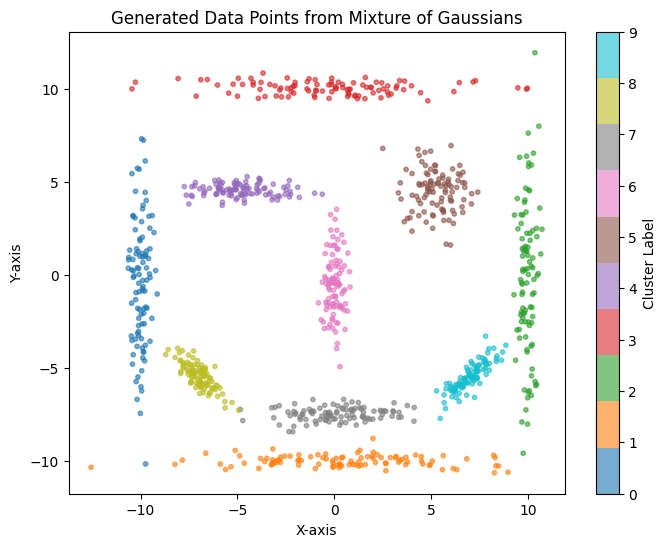

In [14]:
# Visualize the true distribution
plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], alpha=0.6, c=labels, cmap="tab10", s=10)
plt.title("Generated Data Points from Mixture of Gaussians")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.colorbar(label="Cluster Label")

In [15]:
# 1. K-Means Clustering
def run_kmeans(data, n_clusters=3):
    predictions = np.random.randint(0, n_clusters, size=len(data))
    centers = np.random.rand(n_clusters, data.shape[1])
    
    kmeans = KMeans(n_clusters=n_clusters, max_iter=300, random_state=None)
    kmeans.fit(data)
    labels = kmeans.labels_
    centers = kmeans.cluster_centers_
    return labels, centers
    #return predictions, centers

n_clusters = len(pi)
kmeans_predictions, centers = run_kmeans(data, n_clusters)

Text(0.5, 1.0, 'K-Means Clustering')

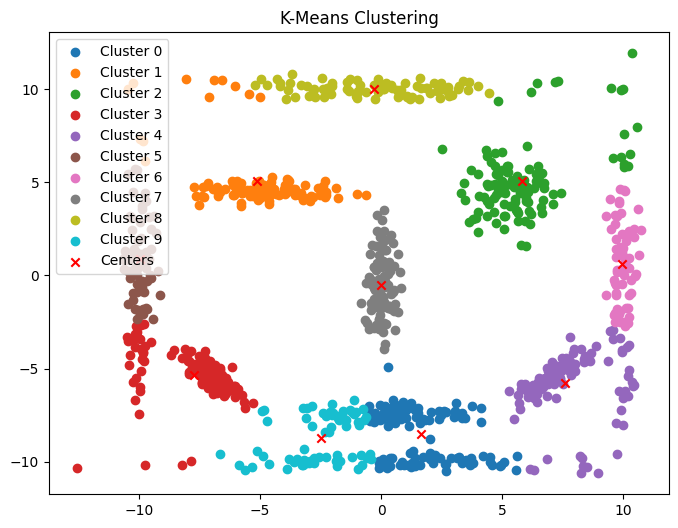

In [16]:
# Plot K-Means Results
plt.figure(figsize=(8, 6))
for i in range(n_clusters):
    plt.scatter(
        data[kmeans_predictions == i, 0], data[kmeans_predictions == i, 1], label=f"Cluster {i}"
    )
plt.scatter(centers[:, 0], centers[:, 1], c="red", marker="x", label="Centers")
plt.legend()
plt.title("K-Means Clustering")

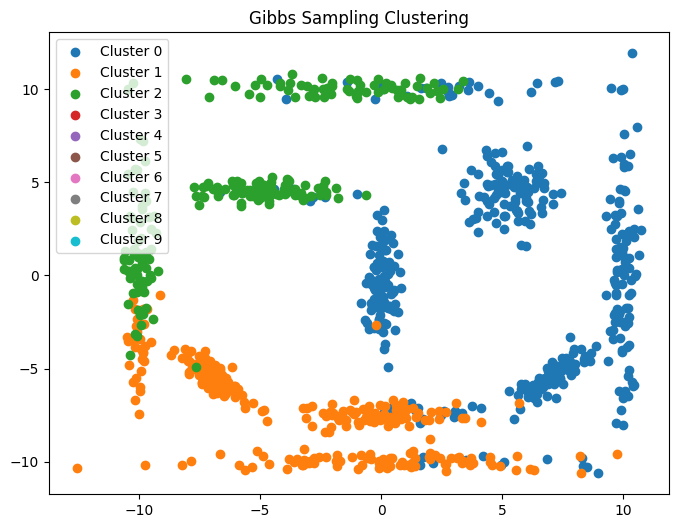

In [17]:
# 2. Gibbs Sampling for Clustering
#def gibbs_sampling(data, n_clusters=3, n_samples=500, burn_in=200):
def gibbs_sampling(data, n_clusters=3, n_samples=1000, burn_in=500):    
    n_points, dim = data.shape
    
    # Initialize random cluster assignments
    cluster_assignments = np.random.choice(n_clusters, n_points)
    
    # Initialize cluster parameters
    cluster_means = np.random.randn(n_clusters, dim)
    cluster_covariances = np.array([np.eye(dim) for _ in range(n_clusters)])
    cluster_counts = np.zeros(n_clusters)
    #alpha = 1.0  # Dirichlet prior
    alpha = 0.5  # Dirichlet prior
    
    
    # Gibbs Sampling
    for _ in range(n_samples + burn_in):
        # Update cluster parameters based on current assignments
        for k in range(n_clusters):
            points_in_cluster = data[cluster_assignments == k]
            cluster_counts[k] = len(points_in_cluster)
            if cluster_counts[k] > 0:
                cluster_means[k] = points_in_cluster.mean(axis=0)
                cluster_covariances[k] = np.cov(points_in_cluster, rowvar=False) + np.eye(dim)
            else:
                cluster_means[k] = np.random.randn(dim)
                cluster_covariances[k] = np.eye(dim)
        
        # Update cluster assignments for each data point
        for i in range(n_points):
            probabilities = []
            for k in range(n_clusters):
                prior = (cluster_counts[k] + alpha) / (n_points + n_clusters * alpha)
                likelihood = multivariate_normal.pdf(data[i], mean=cluster_means[k], cov=cluster_covariances[k])
                probabilities.append(prior * likelihood)
            probabilities = np.array(probabilities)
            probabilities /= probabilities.sum()
            cluster_assignments[i] = np.random.choice(n_clusters, p=probabilities)
    
    return cluster_assignments

# Run Gibbs Sampling
gibbs_predictions = gibbs_sampling(data, n_clusters=3)

# Plot Gibbs Sampling Results
plt.figure(figsize=(8, 6))
for i in range(n_clusters):
    plt.scatter(
        data[gibbs_predictions == i, 0],
        data[gibbs_predictions == i, 1],
        label=f"Cluster {i}",
    )
plt.title("Gibbs Sampling Clustering")
plt.legend()
plt.show()


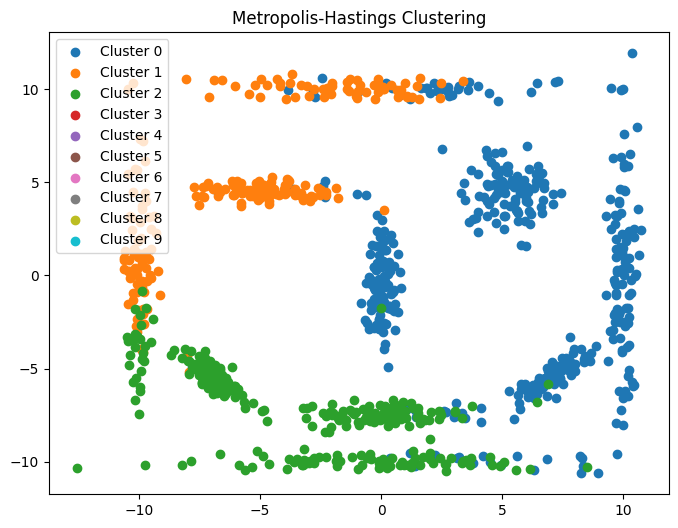

In [18]:
# 3. Metropolis-Hastings for Clustering
def metropolis_hastings(data, n_clusters=3, proposal_std=1.0, n_samples=500, burn_in=200):

    n_points, dim = data.shape
    
    # Initialize random cluster assignments
    cluster_assignments = np.random.choice(n_clusters, n_points)
    
    # Initialize cluster parameters
    cluster_means = np.random.randn(n_clusters, dim)
    cluster_covariances = np.array([np.eye(dim) for _ in range(n_clusters)])
    cluster_counts = np.zeros(n_clusters)
    alpha = 1.0  # Dirichlet prior
    
    # Helper to compute posterior probability
    def posterior_probability(point, cluster_idx):
        prior = (cluster_counts[cluster_idx] + alpha) / (n_points + n_clusters * alpha)
        likelihood = multivariate_normal.pdf(
            point, mean=cluster_means[cluster_idx], cov=cluster_covariances[cluster_idx]
        )
        return prior * likelihood
    
    for _ in range(n_samples + burn_in):
        # Update cluster parameters based on current assignments
        for k in range(n_clusters):
            points_in_cluster = data[cluster_assignments == k]
            cluster_counts[k] = len(points_in_cluster)
            if cluster_counts[k] > 0:
                cluster_means[k] = points_in_cluster.mean(axis=0)
                cluster_covariances[k] = np.cov(points_in_cluster, rowvar=False) + np.eye(dim)
            else:
                cluster_means[k] = np.random.randn(dim)
                cluster_covariances[k] = np.eye(dim)
        
        # Metropolis-Hastings sampling step
        for i in range(n_points):
            current_cluster = cluster_assignments[i]
            
            # Propose a new cluster
            proposed_cluster = np.random.choice(n_clusters)
            
            # Compute posterior probabilities for current and proposed clusters
            current_prob = posterior_probability(data[i], current_cluster)
            proposed_prob = posterior_probability(data[i], proposed_cluster)
            
            # Acceptance ratio
            acceptance_ratio = proposed_prob / current_prob if current_prob > 0 else 1.0
            
            # Accept or reject the proposed cluster
            if np.random.rand() < acceptance_ratio:
                cluster_assignments[i] = proposed_cluster

    return cluster_assignments

# Run Metropolis-Hastings
mh_predictions = metropolis_hastings(data, n_clusters=3)

# Plot Metropolis-Hastings Results
plt.figure(figsize=(8, 6))
for i in range(n_clusters):
    plt.scatter(
        data[mh_predictions == i, 0], data[mh_predictions == i, 1], label=f"Cluster {i}"
    )
plt.title("Metropolis-Hastings Clustering")
plt.legend()
plt.show()


In [19]:
# Evaluate Clustering Results

# Assuming true_labels is a numpy array containing the true labels of the data points
# and kmeans_predictions, gibbs_predictions, mh_predictions are the predicted labels

# Calculate ARI for each clustering method
kmeans_ari = adjusted_rand_score(labels, kmeans_predictions)
gibbs_ari = adjusted_rand_score(labels, gibbs_predictions)
mh_ari = adjusted_rand_score(labels, mh_predictions)

# Print the ARI results
print("Adjusted Rand Index of Clustering Methods:")
print(f"K-Means ARI: {kmeans_ari:.2f}")
print(f"Gibbs Sampling ARI: {gibbs_ari:.2f}")
print(f"Metropolis-Hastings ARI: {mh_ari:.2f}")


Adjusted Rand Index of Clustering Methods:
K-Means ARI: 0.72
Gibbs Sampling ARI: 0.24
Metropolis-Hastings ARI: 0.24


In [20]:
# Compare Results
print("Comparison of Clustering Results:")
print("K-Means Predictions:", np.bincount(kmeans_predictions))
print("Gibbs Sampling Predictions:", np.bincount(gibbs_predictions))
print("Metropolis-Hastings Predictions:", np.bincount(mh_predictions))

Comparison of Clustering Results:
K-Means Predictions: [119 112 117 130 132  69  68  99  83  71]
Gibbs Sampling Predictions: [466 301 233]
Metropolis-Hastings Predictions: [469 233 298]
